In [ ]:
import itertools
import random
import time
import ast
import json
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
### --- Load Dataset (JSON version) --- ###
dataset_path = "/content/drive/MyDrive/Dissertation Work/Research Work/Datasets/medium_circuits.json"

# Load JSON into DataFrame
with open(dataset_path, "r") as f:
    data = json.load(f)

df_circuits = pd.DataFrame(data)

# Ensure numvars is int (if missing, infer from variables length)
if "numvars" in df_circuits.columns:
    df_circuits["numvars"] = df_circuits["numvars"].astype(int)
else:
    df_circuits["numvars"] = df_circuits["variables"].apply(len)

# Quick sanity print
for _, row in df_circuits.iterrows():
    print(row["circuit_name"], len(row["variables"]), len(row["gates"]))

hwb5_54 5 24
hwb6_57 6 65
ham7_104 7 23
cycle17_3_112 20 48
mod5adder_127 6 21
rd53_131 7 28
rd84_142 15 28
0410184_169 14 46
mux_246 22 35
ryy6_256 17 44
squar5_261 13 43
cycle10_293 39 78
hwb5_300 28 88
sym6_316 14 29


###Functions for fault model simulation and fault detection

In [ ]:
def simulate_circuit(circuit, input_vector):
    """Simulate a circuit on a given input vector (no faults)."""
    vec = input_vector.copy()
    for gate in circuit:
        gtype = gate[0].upper()
        if gtype == "TOFFOLI":
            controls, target = gate[1], gate[2]
            if all(vec[c] == 1 for c in controls):
                vec[target] ^= 1
        elif gtype == "FREDKIN":
            controls, s1, s2 = gate[1]
            if all(vec[c] == 1 for c in controls):
                vec[s1], vec[s2] = vec[s2], vec[s1]
    return vec

In [ ]:
# =====================================================
#  FAULT SIMULATORS
# =====================================================

def simulate_faulty_saf(circuit, input_vector, fault):
    vec = input_vector.copy()
    for i, gate in enumerate(circuit):
        if i == fault["location"]:
            vec[fault["wire"]] = fault["value"]
        gtype = gate[0].upper()
        if gtype == "TOFFOLI":
            controls, target = gate[1], gate[2]
            if all(vec[c] == 1 for c in controls):
                vec[target] ^= 1
        elif gtype == "FREDKIN":
            controls, s1, s2 = gate[1]
            if all(vec[c] == 1 for c in controls):
                vec[s1], vec[s2] = vec[s2], vec[s1]
    return vec

def simulate_faulty_mmgf(circuit, input_vector, fault):
    faulty_circuit = [g for i,g in enumerate(circuit) if i != fault["location"]]
    return simulate_circuit(faulty_circuit, input_vector.copy())

def simulate_faulty_smgf(circuit, input_vector, fault):
    return simulate_faulty_mmgf(circuit, input_vector, fault)

def simulate_faulty_pmgf(circuit, input_vector, fault):
    vec = input_vector.copy()
    for i, gate in enumerate(circuit):
        gtype = gate[0].upper()
        if i == fault["location"]:
            if gtype == "TOFFOLI":
                _, target = gate[1], gate[2]
                vec[target] ^= 1  # unconditional flip
            elif gtype == "FREDKIN":
                _, s1, s2 = gate[1]
                vec[s1], vec[s2] = vec[s2], vec[s1]
        else:
            if gtype == "TOFFOLI":
                controls, target = gate[1], gate[2]
                if all(vec[c] == 1 for c in controls):
                    vec[target] ^= 1
            elif gtype == "FREDKIN":
                controls, s1, s2 = gate[1]
                if all(vec[c] == 1 for c in controls):
                    vec[s1], vec[s2] = vec[s2], vec[s1]
    return vec

def simulate_faulty_gaf(circuit, input_vector, fault):
    """
    GAF: Add an extra gate at a given location.
    fault['extra_gate'] should be a valid gate tuple.
    """
    vec = input_vector.copy()
    faulty_circuit = []
    for i, gate in enumerate(circuit):
        if i == fault["location"]:
            faulty_circuit.append(fault["extra_gate"])  # insert before the real gate
        faulty_circuit.append(gate)
    return simulate_circuit(faulty_circuit, vec)


def simulate_faulty_caf(circuit, input_vector, fault):
    """
    CAF: Control Appearance Fault.
    Add an extra control line to the gate at fault['location'].
    """
    vec = input_vector.copy()
    faulty_circuit = []
    for i, gate in enumerate(circuit):
        gtype = gate[0].upper()
        if i == fault["location"]:
            if gtype == "TOFFOLI":
                controls, target = gate[1], gate[2]
                # add the extra control if not already present
                new_controls = list(controls)
                if fault["control"] not in new_controls:
                    new_controls.append(fault["control"])
                faulty_circuit.append(("TOFFOLI", new_controls, target))
            elif gtype == "FREDKIN":
                controls, s1, s2 = gate[1]
                new_controls = list(controls)
                if fault["control"] not in new_controls:
                    new_controls.append(fault["control"])
                faulty_circuit.append(("FREDKIN", (new_controls, s1, s2)))
            else:
                faulty_circuit.append(gate)
        else:
            faulty_circuit.append(gate)
    return simulate_circuit(faulty_circuit, vec)


def simulate_faulty_bf(circuit, input_vector, fault):
    """
    BF: Bridging Fault – wires shorted together (AND or OR).
    """
    vec = input_vector.copy()
    for gate in circuit:
        gtype = gate[0].upper()
        if gtype == "TOFFOLI":
            controls, target = gate[1], gate[2]
            if all(vec[c] == 1 for c in controls):
                vec[target] ^= 1
        elif gtype == "FREDKIN":
            controls, s1, s2 = gate[1]
            if all(vec[c] == 1 for c in controls):
                vec[s1], vec[s2] = vec[s2], vec[s1]

        # Apply bridging after each gate
        if fault["mode"] == "AND":
            val = vec[fault["wire1"]] & vec[fault["wire2"]]
        else:  # OR
            val = vec[fault["wire1"]] | vec[fault["wire2"]]
        vec[fault["wire1"]] = vec[fault["wire2"]] = val
    return vec



In [ ]:
def generate_fault_list_with_types(circuit, n_inputs, include=("SAF","SMGF","MMGF","PMGF")):
    fault_list = []

    if "SAF" in include:
        for gate_idx in range(len(circuit)):
            for wire in range(n_inputs):
                for val in [0, 1]:
                    fault_list.append({
                        "id": f"SAF_{gate_idx}_{wire}_{val}",
                        "type": "SAF",
                        "location": gate_idx,
                        "wire": wire,
                        "value": val
                    })
    if "SMGF" in include:
        for i in range(len(circuit)):
            fault_list.append({"id": f"SMGF_{i}", "type": "SMGF", "location": i})
    if "MMGF" in include:
        for i in range(len(circuit)):
            fault_list.append({"id": f"MMGF_{i}", "type": "MMGF", "location": i})
    if "PMGF" in include:
        for i in range(len(circuit)):
            fault_list.append({"id": f"PMGF_{i}", "type": "PMGF", "location": i})

    if "GAF" in include:
        for i in range(len(circuit)):
            fault_list.append({
                "id": f"GAF_{i}",
                "type": "GAF",
                "location": i,
                "extra_gate": ("TOFFOLI", [], 0)  # unconditional NOT on wire 0
            })

    if "CAF" in include:
        for i in range(len(circuit)):
            for w in range(n_inputs):
                fault_list.append({
                    "id": f"CAF_{i}_{w}",
                    "type": "CAF",
                    "location": i,
                    "control": w
                })

    if "BF" in include:
        for w1 in range(n_inputs):
            for w2 in range(w1+1, n_inputs):
                for mode in ["AND","OR"]:
                    fault_list.append({
                        "id": f"BF_{w1}_{w2}_{mode}",
                        "type": "BF",
                        "wire1": w1,
                        "wire2": w2,
                        "mode": mode
                    })
    return fault_list



In [ ]:
def detect_fault(dp, vector, fault, circuit, normal_cache):
    vkey = tuple(vector)
    if vkey not in normal_cache:
        normal_cache[vkey] = simulate_circuit(circuit, vector)
    normal_output = normal_cache[vkey]

    key = (vkey, fault["id"])
    if key in dp:
        return dp[key]

    if fault["type"] == "SAF":
        faulty_output = simulate_faulty_saf(circuit, vector, fault)
    elif fault["type"] == "SMGF":
        faulty_output = simulate_faulty_smgf(circuit, vector, fault)
    elif fault["type"] == "MMGF":
        faulty_output = simulate_faulty_mmgf(circuit, vector, fault)
    elif fault["type"] == "PMGF":
        faulty_output = simulate_faulty_pmgf(circuit, vector, fault)
    elif fault["type"] == "GAF":
        faulty_output = simulate_faulty_gaf(circuit, vector, fault)
    elif fault["type"] == "CAF":
        faulty_output = simulate_faulty_caf(circuit, vector, fault)
    elif fault["type"] == "BF":
        faulty_output = simulate_faulty_bf(circuit, vector, fault)

    else:
        raise ValueError(f"Unknown fault type: {fault['type']}")

    detected = normal_output != faulty_output
    dp[key] = detected
    return detected

###Fitness Calulation

In [ ]:
def compute_fitness(individual, fault_list, circuit, dp, normal_cache, alpha=100, beta=0.01):
    detected_faults = set()
    # (no local normal_cache here)
    for vector in individual:
        for fault in fault_list:
            if detect_fault(dp, vector, fault, circuit, normal_cache):
                detected_faults.add(fault["id"])
    coverage = len(detected_faults) / len(fault_list) if fault_list else 0.0
    if coverage < 1.0:
        fitness = alpha * coverage
    else:
        fitness = alpha * coverage - beta * len(individual)
    return fitness, coverage, detected_faults


###Mutation and Crossover

In [ ]:
# ---------- GA Operators ---------- #
def crossover(parent1, parent2):
    cut1 = random.randint(1, len(parent1) - 1)
    cut2 = random.randint(1, len(parent2) - 1)
    return parent1[:cut1] + parent2[cut2:]

def mutate(individual, mutation_rate=0.2):
    for vec in individual:
        if random.random() < mutation_rate:
            bit = random.randint(0, len(vec) - 1)
            vec[bit] ^= 1
    return individual

In [ ]:
def remove_redundant_vectors(individual, circuit, fault_list):
    reduced = []
    dp = {}
    normal_cache = {}
    covered = set()
    for vec in individual:
        temp = covered.copy()
        for fault in fault_list:
            if fault["id"] not in covered and detect_fault(dp, vec, fault, circuit, normal_cache):
                covered.add(fault["id"])
        if temp != covered:
            reduced.append(vec)
    return reduced

###GA+DP Approach

In [ ]:
def run_ga(
    circuit, n_inputs,
    fault_models=("SAF",),
    generations=100, pop_size=50, max_vecs=50, runs=3,
    mutation_rate=0.2, elitism=2
):
    fault_list = generate_fault_list_with_types(circuit, n_inputs, include=fault_models)
    best_results = []

    # Pre-cache: all fault-free outputs for every possible vector (saves repeated sim)
    normal_cache = {}
    dp = {}

    for _ in range(runs):
        # --- population init ---
        population = [
            [[random.randint(0, 1) for _ in range(n_inputs)]
             for _ in range(random.randint(2, max_vecs))]
            for _ in range(pop_size)
        ]

        best = None
        best_score = -1e9

        for gen in range(generations):
            # --- evaluate all individuals once ---
            fitness_data = []
            for ind in population:
                fitness, coverage, detected = compute_fitness(ind, fault_list, circuit, dp, normal_cache)
                fitness_data.append((fitness, ind, coverage, detected))
                if fitness > best_score:
                    best, best_score, best_cov, best_detected = ind, fitness, coverage, detected

            # --- sort population by fitness (descending) ---
            fitness_data.sort(key=lambda x: x[0], reverse=True)
            sorted_pop = [ind for (_, ind, _, _) in fitness_data]

            # --- elitism: keep top k parents ---
            next_gen = sorted_pop[:elitism]

            # --- breed rest ---
            while len(next_gen) < pop_size:
                p1, p2 = random.sample(sorted_pop[:pop_size // 2], 2)
                child = crossover(p1, p2)
                child = mutate(child, mutation_rate=mutation_rate)
                next_gen.append(child)
            population = next_gen

            # --- early stop: 100% coverage ---
            if best_cov == 1.0:
                break

        # --- redundancy removal (final best) ---
        best = remove_redundant_vectors(best, circuit, fault_list)
        best_fitness, coverage, detected_faults = compute_fitness(best, fault_list, circuit, dp, normal_cache)
        best_results.append((best, (best_fitness, coverage, len(fault_list), detected_faults)))

    return best_results

###Run over the benchmark circuits

In [ ]:
def convert_dataset_gates(dataset_gates, variables):
    if isinstance(variables,str):
        variables = ast.literal_eval(variables)
    var_map = {v:i for i,v in enumerate(variables)}
    circuit = []
    for g in dataset_gates:
        if not isinstance(g,dict) or "gate" not in g or "vars" not in g:
            continue
        gate_name = str(g["gate"]).lower()
        idxs = [var_map[n] for n in g["vars"] if n in var_map]
        if len(idxs)==0: continue
        if gate_name.startswith("t"):
            controls, target = ([],idxs[0]) if len(idxs)==1 else (idxs[:-1], idxs[-1])
            circuit.append(("TOFFOLI",controls,target))
        elif gate_name.startswith("f"):
            if len(idxs)<2: continue
            controls, s1, s2 = idxs[:-2], idxs[-2], idxs[-1]
            circuit.append(("FREDKIN",(controls,s1,s2)))
    return circuit


In [ ]:
def run_on_dataset(df, save_csv_path="ga_results.csv", fault_models=("SAF",)):
    results = []
    if isinstance(fault_models, str):
        fault_models = (fault_models,)
    for _, row in df.iterrows():
        circuit = convert_dataset_gates(row["gates"], row["variables"])
        n_inputs = int(row["numvars"])

        if not circuit:
            print(f"⚠️ {row['circuit_name']} → Empty/unsupported circuit.")
            continue

        start = time.time()
        best_runs = run_ga(circuit, n_inputs, fault_models=fault_models)
        end = time.time()

        best_test_set, (fitness, coverage, total_faults, detected_faults) = max(best_runs, key=lambda x: x[1][0])
        results.append({
            "file": row['circuit_name'],
            "fitness": round(fitness,4),
            "coverage": round(coverage,4),
            "total_faults": total_faults,
            "detected_faults": len(detected_faults),
            "num_test_vectors": len(best_test_set),
            "num_gates": len(circuit),
            "exec_time_sec": round(end-start,2)
        })

    with open(save_csv_path,"w",newline="") as f:
        writer = csv.DictWriter(f, fieldnames=["file","fitness","coverage","total_faults","detected_faults","num_test_vectors","num_gates","exec_time_sec"])
        writer.writeheader()
        for r in results: writer.writerow(r)
    return results

###Visualiza the Results

In [ ]:
def plot_gates_coverage_vectors(results):
    files = [r["file"] for r in results]
    num_gates = [r["num_gates"] for r in results]
    coverage = [r["coverage"] for r in results]
    num_vectors = [r["num_test_vectors"] for r in results]

    x = np.arange(len(files))
    fig, ax1 = plt.subplots(figsize=(14, 6))
    bars = ax1.bar(x - 0.2, num_gates, width=0.4, color='lightcoral', label="Gate Count")
    ax1.set_ylabel("Number of Gates", color="lightcoral")
    ax1.tick_params(axis='y', labelcolor="lightcoral")
    ax1.set_xticks(x)
    ax1.set_xticklabels(files, rotation=45, ha='right')

    ax2 = ax1.twinx()
    ax2.plot(x, coverage, marker='o', label="Fault Coverage")
    ax2.set_ylabel("Coverage")
    ax2.set_ylim(0, 1.05)

    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.plot(x, num_vectors, marker='s', linestyle='--', label="Test Vectors")
    ax3.set_ylabel("Number of Test Vectors")

    plt.title("Gates, Coverage & Test Vectors per Circuit")
    fig.tight_layout()
    plt.show()


def plot_coverage_vs_vectors(results):
    x = [r["num_test_vectors"] for r in results]
    y = [r["coverage"] for r in results]
    labels = [r["file"] for r in results]
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, s=100)
    for i, label in enumerate(labels):
        plt.text(x[i] + 0.02, y[i], label, fontsize=9)
    plt.xlabel("Number of Test Vectors")
    plt.ylabel("Fault Coverage")
    plt.title("Coverage vs Number of Test Vectors")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_efficiency(results):
    efficiency = [(r["detected_faults"] / r["num_test_vectors"]) if r["num_test_vectors"] else 0 for r in results]
    labels = [r["file"] for r in results]
    plt.figure(figsize=(10, 5))
    plt.bar(labels, efficiency)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Efficiency (Detected Faults per Vector)")
    plt.title("Test Vector Efficiency per Circuit")
    plt.tight_layout()
    plt.show()

In [ ]:
# Run GA + DP on the dataset
results = run_on_dataset(df_circuits, save_csv_path="/content/drive/MyDrive/Dissertation Work/Research Work/results/medium_smgf.csv", fault_models=('SMGF'))

In [ ]:
def plot_faults_per_circuit(results):
    filtered = [r for r in results if r["fitness"] != "ERROR"]
    files = [r["file"] for r in filtered]
    total_faults = [r["total_faults"] for r in filtered]
    detected_faults = [r["detected_faults"] for r in filtered]

    x = np.arange(len(files))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    bar1 = ax.bar(x - width/2, total_faults, width, label="Total Faults", color='lightgray')
    bar2 = ax.bar(x + width/2, detected_faults, width, label="Detected Faults", color='mediumseagreen')

    ax.set_xlabel("Circuit")
    ax.set_ylabel("Number of Faults")
    ax.set_title("Total vs Detected Faults per Circuit")
    ax.set_xticks(x)
    ax.set_xticklabels(files, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y')

    plt.tight_layout()
    plt.show()


In [ ]:
for r in results:
    print(f'{r["file"]} → gates: {r.get("num_gates")}, vectors: {r.get("num_test_vectors")}, time: {r.get("exec_time_sec")} sec')



hwb5_54 → gates: 24, vectors: 7, time: 0.08 sec
hwb6_57 → gates: 65, vectors: 9, time: 0.43 sec
ham7_104 → gates: 23, vectors: 4, time: 0.12 sec
cycle17_3_112 → gates: 48, vectors: 14, time: 2160.11 sec
mod5adder_127 → gates: 21, vectors: 5, time: 0.08 sec
rd53_131 → gates: 28, vectors: 5, time: 0.15 sec
rd84_142 → gates: 28, vectors: 6, time: 2.61 sec
0410184_169 → gates: 46, vectors: 4, time: 6.94 sec
mux_246 → gates: 35, vectors: 21, time: 8.72 sec
ryy6_256 → gates: 44, vectors: 14, time: 2309.88 sec
squar5_261 → gates: 43, vectors: 9, time: 5.57 sec
cycle10_293 → gates: 78, vectors: 7, time: 20.36 sec
hwb5_300 → gates: 88, vectors: 6, time: 28.14 sec
sym6_316 → gates: 29, vectors: 7, time: 4.15 sec


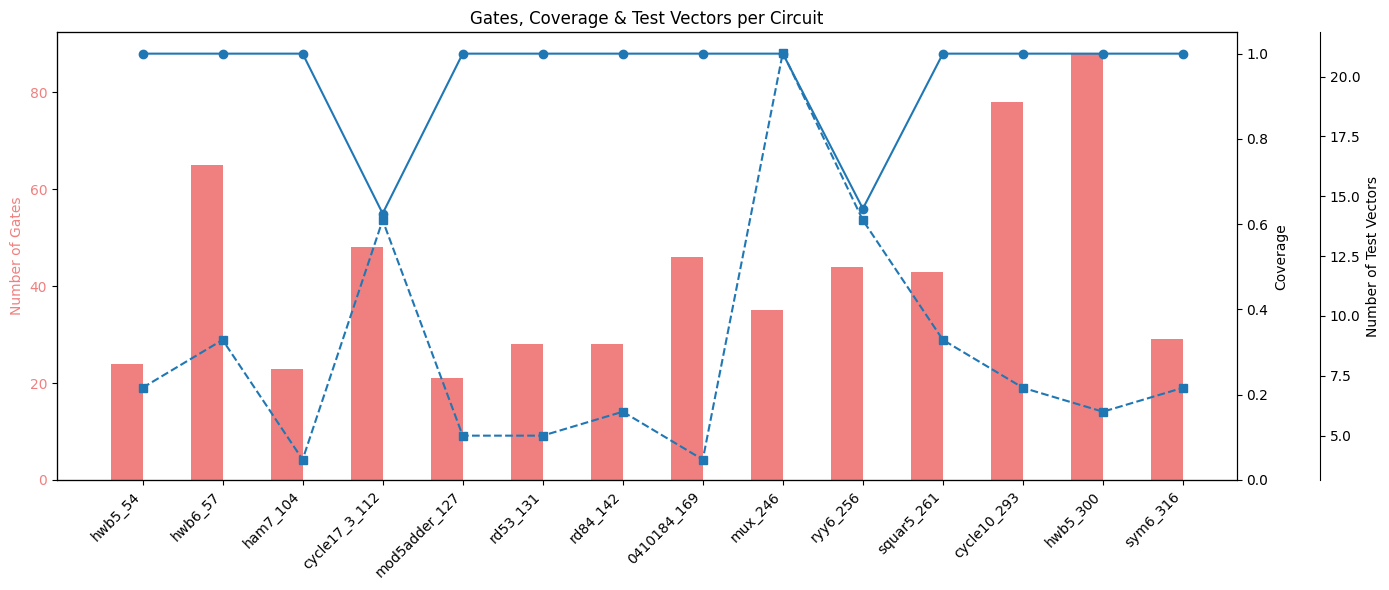

In [ ]:
plot_gates_coverage_vectors(results)


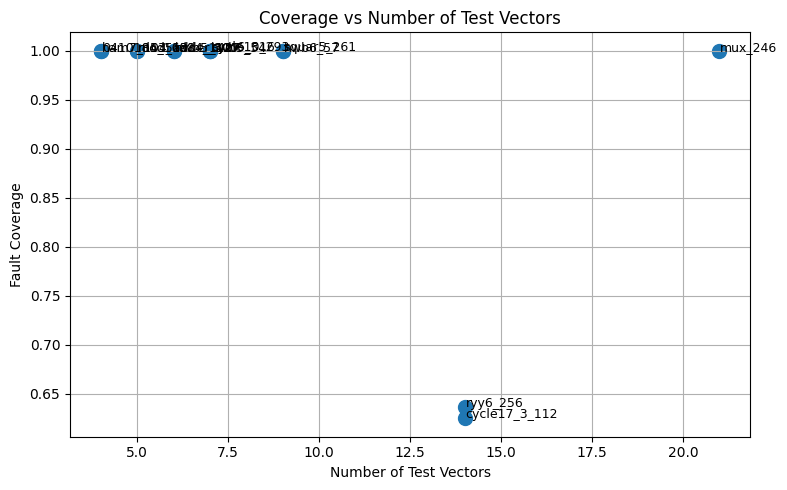

In [ ]:
plot_coverage_vs_vectors(results)

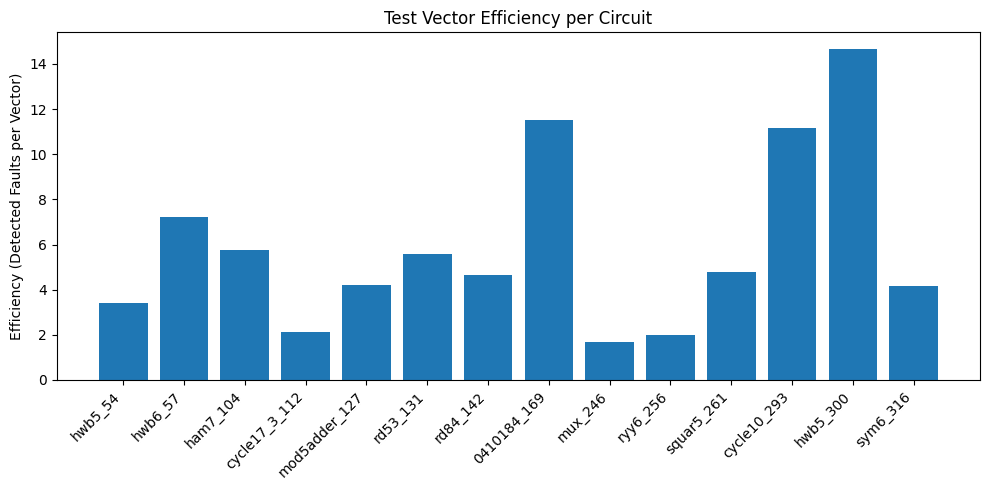

In [ ]:
plot_efficiency(results)
# ---------- Example Execution ---------- #


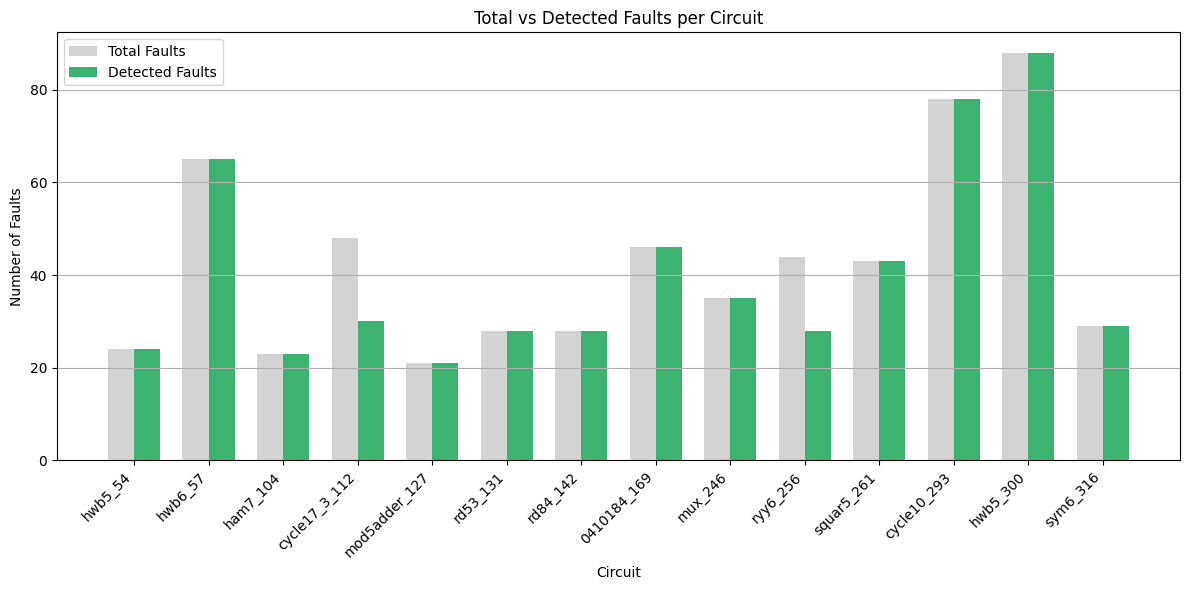

In [ ]:
plot_faults_per_circuit(results)
